# Variational Quantum Classifier (VQC)

Hybrid Quantum-Classical model that uses classical computer to manage the logic and a quantum computer to do the data representation:

- The Quantum Part: Uses a quantum circuit to map input data to a quantum state.
-  The Classical Part: Uses a classical optimizer to train quantum parameters

### Why is VQC Useful Compared to Classical Classifier?

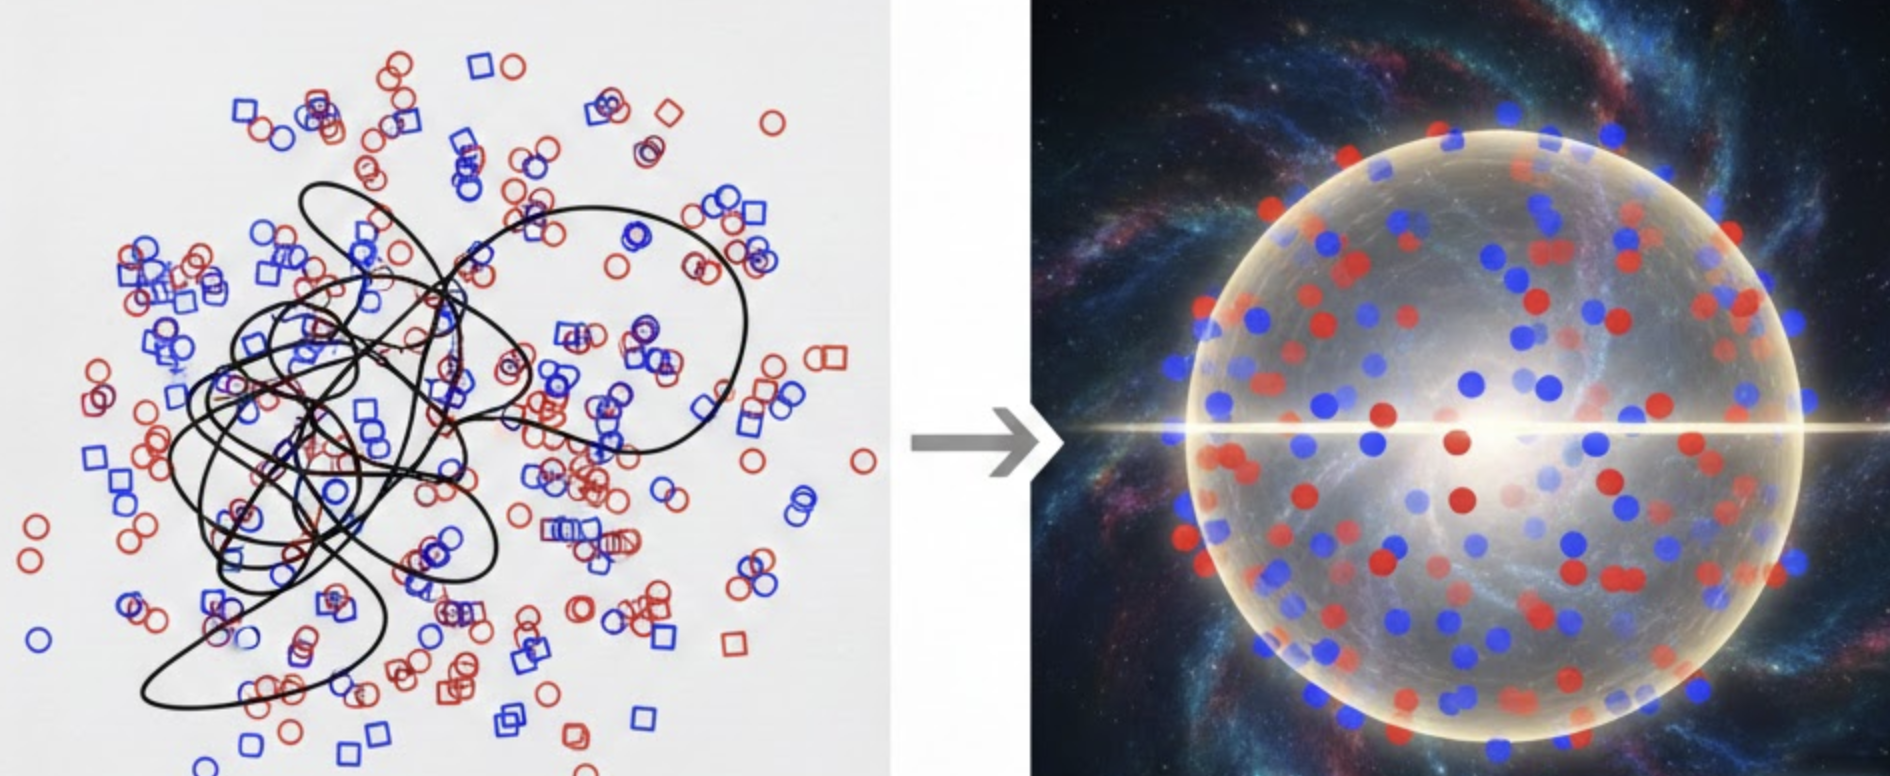

**Intuition**: For Classical ML, the data lives in low-dimensional "flat" space, and when more variables are added, the computational math becomes a heavy burden for the processor. Whereas using Quantum ML, the Quantum Feature Space (Hilbert Space), the scale of increase is represented by the Hilbert Space $H$ for $n$ qubits is $\text{Dim}(H) = 2^n$. Every time a Qubit is added, the dimension increases exponentially.

#### Classical Classifier (SVM)

SVM separates data in a feature space: $x \rightarrow \phi(x) \in \mathbb{R}^D$

| Kernel | Feature space size |
| -- | -- |
| Linear | $d$ |
| Polynomial degree $k$ | $O(d^k)$ |
| RBF | Infinite (implicit) |

#### Quantum Classifier (VQC)

For $n$ qubits: $\text{Dim}(H) = 2^n$

So the quantum state lives in a vector space like: $|\psi\rangle \in \mathbb{C}^{2^n}$

| Qubits | Dimension |
| -- | -- |
| 1 | 2 |
| 2 | 4 | 
| 3 | 8 |
| $n$ | $2^n$ |

### Time Complexity Comparison

| | Classical Kernel (SVM) | Quantum Kernel (VQC) | 
| -- | -- | -- |
| **Kernel** | $K(x_i,x_j)=\phi(x_i)\cdot\phi(x_j)$ | $K=\|\langle\psi(x_i)\|\psi(x_j)\rangle\|^2$ |
| **Time Complexity** | Exponential | Polynomial |
| | Cost depends on feature dimension $D$, so if $D=2^n$, then its $O(2^n)$ | It is computed via circuit overlap, so $O(n^k)$, where $k$ is some integer |

Note that circuit depth can affect $k$ but its not equal to $k$.

#### Understanding Circuit Depth

Example of depth = `1`,

```
Layer 1:
q0 ─ H ─
q1 ─ H ─
q2 ─ H ─
```

Example of depth = `3`,

```
q0 ─ H ─ RZ ─ RX ─
```

In [32]:
! pip3 install qiskit-machine-learning qiskit-algorithms numpy --break-system-packages

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import Aer
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import Optimize1qGatesDecomposition, CommutativeCancellation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

#### Step 1: Generate and Preprocess Data

Creates a 2‑feature synthetic classification dataset, standardizes features, and splits into train/test. 

In [34]:
X, y = make_classification(
    n_samples=100,
    n_features=2,      # Total number of features
    n_informative=2,   # Ensure sum ≤ total features
    n_redundant=0,     # No redundant features
    n_clusters_per_class=1,
    random_state=42
)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#### Step 2: Define Quantum Feature Map

To encode classical data into a quantum state; this is the input embedding for the classifier.

-----

For example, Layer 1,

```
q0 ──RZ(x1)──■────────
             │ ZZ(x1x2)
q1 ──RZ(x2)──■────────
```

Layer 2 will repeat the same encoding layer format (`reps=2` means `2` encoding layers)

In [35]:
feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='linear')

/var/folders/td/rtvtvvjn3x1gfqswnc7bb6hm0000gn/T/ipykernel_56766/2133380198.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement='linear')


#### Step 3: Define Variational Quantum Circuit (Ansatz)

Provides trainable parameters (weights) that the optimizer will adjust to separate classes.

----

```
Layer 1: Ry(θ0) ──■──── Ry(θ2) ──■──── Ry(θ4)
                  │               │
         Ry(θ1) ──X──── Ry(θ3) ──X──── Ry(θ5)
```

The weights are represented as `θ`.

In [36]:
ansatz = RealAmplitudes(num_qubits=2, reps=3, entanglement='linear')

/var/folders/td/rtvtvvjn3x1gfqswnc7bb6hm0000gn/T/ipykernel_56766/2662761407.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=3, entanglement='linear')


#### Step 4: Initialize the State Vector Sampler

Statevector simulation gives exact amplitudes (no sampling noise), ideal for a clean sample for estimations.

In [37]:
sampler = StatevectorSampler()

#### Step 5: Define Fidelity Quantum Kernel

Computes state overlap as a similarity measure in the quantum feature space, so that we can compute similarity without explicitly working entirely in the $2ⁿ$ space.

In [38]:
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=sampler)

#### Step 6: Instantiate the Optimizer

COBYLA is gradient‑free and robust for noisy or non‑smooth cost landscapes typical of variational circuits.

What is tries to solve is: $\theta^* = \arg\min_\theta L(\theta)$

Where, $L(\theta) =\text{Loss}\big(\text{Measurement}(U(x,\theta))\big)$

-----

**Step 1: Starts with random weights**

```
Loss landscape:

        /\ 
       /  \
  ____/    \____
       ^
     you start here
```

**Step 2: Tries with "nearby" settings**

Instead of using gradients, it probes around:

```
Try left  → loss = 0.42
Try right → loss = 0.35  ← better

        /\ 
       /  \
  ____/    \____
           ^
         moved
```

**Step 3: Repeat probing until it reaches a valley**

COBYLA keeps testing directions like walking downhill blindfolded but feeling the slope locally, until it reaches a valley.

```
Try small changes in θ
Run circuit
Measure loss
Keep improvements

        /\ 
       /  \
  ____/    \____
          \__/
           ↓
        optimal θ
```

In [39]:
optimizer = COBYLA(maxiter=100)

#### Step 7: Define a Custom Pass Manager for Transpilation

Simplifies circuits and reduces warnings during transpilation, leading to cleaner execution.

In [40]:
pass_manager = PassManager(
    Optimize1qGatesDecomposition(basis=['u3', 'cx']),
    CommutativeCancellation()
)

#### Step 8: Define the Variational Quantum Classifier (VQC)

This is the actual model that combines embedding + trainable circuit + optimizer into a classifier.

----

```
Data Encoding        Trainable Circuit       Measurement
──────────────       ───────────────────     ───────────

q0 ──RZ(x1)──■──RZ(x1)──■──RY(θ0)──■──RY(θ2)──■──M
             │          │          │          │
q1 ──RZ(x2)──■──RZ(x2)──■──RY(θ1)──■──RY(θ3)──■──M
```

In [ ]:
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    sampler=sampler,
    pass_manager=pass_manager # provided to avoid transpilation warnings
)

#### Step 9: Train the VQC Model

Optimizes circuit parameters to minimize classification loss on training data.

In [42]:
vqc.fit(X_train, y_train)

#### Step 10: Evaluate the Model

Predicts on `X_test` and computes accuracy, and measures generalization performance on unseen data.

In [43]:
y_pred = vqc.predict(X_test)

# Calculate its accuracy
accuracy = np.mean(y_pred == y_test)
accuracy * 100

np.float64(75.0)